<a href="https://colab.research.google.com/github/adilshahar17/SpeechEmotionRecognition/blob/main/SER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import librosa, librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models

In [17]:
import kagglehub
DATA_PATH = kagglehub.dataset_download("amitgm1994/ravdees-dataset")

Using Colab cache for faster access to the 'ravdees-dataset' dataset.


In [19]:
import os
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfccs

def prepare_dataset(data_path):
    file_paths, features, labels = [], [], []

    for root, dirs, files in os.walk(data_path):
        for f in files:
            if f.endswith(".wav"):
                parts = f.split("-")
                emotion_code = parts[2]
                emotion = emotion_map.get(emotion_code, "unknown")


                file_path = os.path.join(root, f)
                mfccs = extract_features(file_path)

                file_paths.append(file_path)
                features.append(mfccs)
                labels.append(emotion)
    df = pd.DataFrame(features)
    df["label"] = labels
    df["file_path"] = file_paths

    return df

In [23]:
df = prepare_dataset(DATA_PATH)
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1168, 42)
            0          1          2          3          4         5  \
0 -378.050293  54.585274 -60.202915  11.499880 -39.407330 -4.632720   
1 -501.459534  64.830643 -34.118290  20.763788 -20.291079  2.457516   
2 -505.356903  58.828762 -39.975494  16.023653 -17.210375 -7.834851   
3 -603.711182  76.286842 -29.460962  21.211519 -21.722437  8.893651   
4 -644.008301  81.844994 -22.598421  22.512257 -17.848915  2.779891   

           6          7          8         9  ...        32        33  \
0 -14.720495 -18.098810 -13.022308 -9.158742  ...  0.229695 -1.818328   
1 -12.608168  -9.051620  -4.919868 -1.234008  ...  4.354906  1.791558   
2 -19.125723 -15.402801  -5.591331 -5.380417  ...  7.289366  1.310055   
3 -16.997240 -10.997068  -5.637524 -3.243512  ...  5.322347  3.834848   
4 -18.734180 -11.369311 -12.062188 -5.467263  ...  1.337216 -0.471629   

         34        35        36        37        38        39    label  \
0  4.412998 -0.281671  2.290766  0

Classification Report:
               precision    recall  f1-score   support

       angry       0.64      0.58      0.61        36
     disgust       0.50      0.64      0.56        36
     fearful       0.61      0.69      0.65        36
       happy       0.54      0.43      0.48        35
     neutral       0.88      0.39      0.54        18
         sad       0.59      0.46      0.52        37
   surprised       0.53      0.72      0.61        36

    accuracy                           0.57       234
   macro avg       0.61      0.56      0.57       234
weighted avg       0.59      0.57      0.57       234



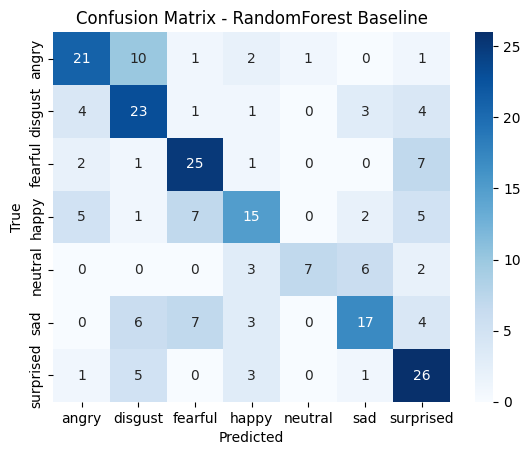

In [21]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["label", "file_path"]).values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - RandomForest Baseline")
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

# Prepare features and labels
X = df.drop(columns=["label", "file_path"]).values
y = df["label"].values

# Encode labels to integers
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Reshape for CNN (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build CNN model
model = models.Sequential([
    layers.Conv1D(64, kernel_size=5, strides=1, activation="relu", input_shape=(40,1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(128, kernel_size=5, strides=1, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(encoder.classes_), activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.2f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2492 - loss: 2.3411 - val_accuracy: 0.2051 - val_loss: 1.9838
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4254 - loss: 1.5530 - val_accuracy: 0.3120 - val_loss: 1.7512
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5048 - loss: 1.3230 - val_accuracy: 0.3333 - val_loss: 1.6821
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5812 - loss: 1.1670 - val_accuracy: 0.3462 - val_loss: 1.6288
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5911 - loss: 1.1255 - val_accuracy: 0.4615 - val_loss: 1.4100
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6123 - loss: 0.9550 - val_accuracy: 0.4915 - val_loss: 1.3614
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6815 - loss: 0.8449 - val_accuracy: 0.5171 - val_loss: 1.3384
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7771 - loss: 0.6834 - val_accuracy: 0.4915 - val

In [27]:
model.save("emotion_model.h5")
np.save("classes.npy", encoder.classes_)

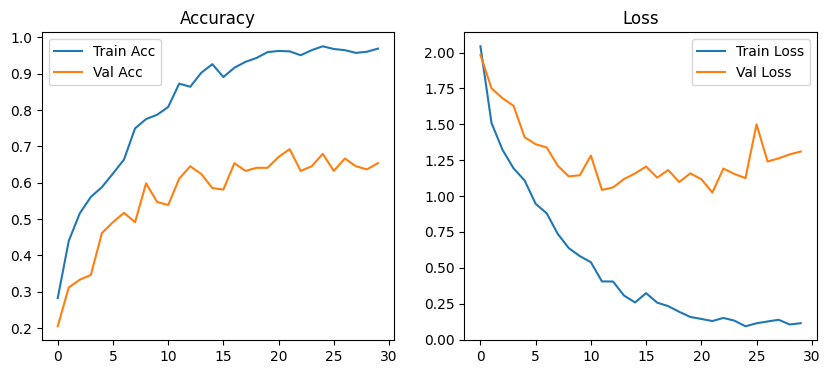

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()